# Recommender Pipeline and Cross-Validation
## Does the Algorithm Hide Europe?

**Team:** Max Priessnitz & Nico [surname]  
**Purpose:** focused modelling notebook for the cultural-prominence audit  

This notebook documents the actual recommendation pipeline and the cross-validation robustness check. It is intentionally narrower than the proposal notebook: it focuses on model implementation, validation design, model comparison and interpretation.


## 1. Modelling Objective

The modelling task is to produce Top-20 movie recommendations from real M3L/MovieLens interaction histories and then audit whether those rankings make European, non-English and long-tail films visible. The models are not evaluated only by accuracy. They are evaluated by a combined governance frame:

- **Utility:** NDCG@20, Recall@20 and MAP@20.
- **Catalogue use:** Coverage@20.
- **Cultural prominence:** discounted group exposure and PACPG.
- **Robustness:** user-fold cross-validation across non-overlapping user subsets.

The cross-validation step uses the existing M3L train/test split inside each user fold. This preserves the recommender setting: each fold has real user histories and real held-out test items.


In [1]:
from pathlib import Path
import subprocess
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path("..").resolve()
OUTPUTS = PROJECT_ROOT / "outputs"
SCRIPT = PROJECT_ROOT / "scripts" / "run_recommender_cross_validation.py"

TOP_K = 20
RUN_CV = False  # Set to True to rerun the full fold pipeline from this notebook.


## 2. Reproducible Pipeline Contract

The implementation lives in `scripts/run_recommender_cross_validation.py`. Keeping the heavy model code in a script gives us a reliable rerun path, while this notebook keeps the reasoning, outputs and interpretation readable.

The script performs these steps per fold:

1. Load real M3L interactions and cached processed movie metadata.
2. Select eligible users with at least five train interactions and at least one test interaction.
3. Split sampled users into three non-overlapping folds.
4. Build a fold-specific sparse user-item matrix and candidate universe.
5. Fit/recompute Popularity, ItemKNN, SVD, MPNet-content, CLIP-image-content and Hybrid scores.
6. Apply governance-aware re-ranking to the Hybrid candidate list.
7. Evaluate utility, coverage, exposure and PACPG.

No synthetic fallback is used.


In [2]:
if RUN_CV:
    completed = subprocess.run(
        [sys.executable, str(SCRIPT)],
        cwd=PROJECT_ROOT,
        check=True,
        text=True,
        capture_output=True,
    )
    print(completed.stdout[-4000:])
else:
    print("Using cached cross-validation outputs. Set RUN_CV=True to rerun the fold pipeline.")


Using cached cross-validation outputs. Set RUN_CV=True to rerun the fold pipeline.


## 3. Cross-Validation Protocol

This is a **user-fold robustness check**, not a random interaction split. A random interaction split would mix user histories in a way that is less faithful to recommendation. Instead, the fold unit is the user: each fold rebuilds the model pipeline on a different set of real users and evaluates against their M3L test items.


In [3]:
cv_run_report = pd.read_csv(OUTPUTS / "15_cv_run_report.csv")
cv_fold_results = pd.read_csv(OUTPUTS / "15_cv_fold_results.csv")
cv_model_summary = pd.read_csv(OUTPUTS / "15_cv_model_summary.csv")

display(cv_run_report)


,setting,value
0,folds,3
1,sampled users,3000
2,users per fold,1000
3,top popular candidate items,4000
4,candidate rerank pool,100
5,top k,20


## 4. Model Ledger

| Model | Implementation | Role in the audit |
|---|---|---|
| Popularity | Global log-popularity score from training interactions. | Mainstream-concentration baseline. |
| ItemKNN | Cosine similarity over the item-user matrix, retaining strongest neighbours. | Transparent collaborative filtering baseline. |
| SVD | TruncatedSVD over the sparse user-item matrix. | Lightweight latent-factor baseline. |
| MPNet-content | User profile from mean text embeddings of train items. | Text-aware content recommender. |
| CLIP-image-content | User profile from mean poster embeddings of train items. | Visual-content recommender. |
| Hybrid | 0.50 SVD + 0.25 MPNet + 0.25 CLIP after row-wise standardisation. | Main multimodal model. |
| Hybrid + re-ranking | Post-processes the Hybrid Top-100 candidate pool with a cultural-prominence bonus. | Governance intervention with explicit lambda. |


In [4]:
cv_model_summary["Absolute PACPG mean"] = (
    cv_model_summary["PACPG European mean"].abs()
    + cv_model_summary["PACPG Non-English mean"].abs()
    + cv_model_summary["PACPG Long-tail mean"].abs()
)
cv_model_summary["Absolute PACPG std proxy"] = (
    cv_model_summary["PACPG European std"].fillna(0).abs()
    + cv_model_summary["PACPG Non-English std"].fillna(0).abs()
    + cv_model_summary["PACPG Long-tail std"].fillna(0).abs()
)

summary_cols = [
    "Model",
    f"NDCG@{TOP_K} mean",
    f"NDCG@{TOP_K} std",
    f"Recall@{TOP_K} mean",
    f"MAP@{TOP_K} mean",
    f"Coverage@{TOP_K} mean",
    "European Exposure@20 mean",
    "Non-English Exposure@20 mean",
    "Long-tail Exposure@20 mean",
    "Absolute PACPG mean",
]
display(cv_model_summary[summary_cols].round(4))


,Model,NDCG@20 mean,NDCG@20 std,Recall@20 mean,MAP@20 mean,Coverage@20 mean,European Exposure@20 mean,Non-English Exposure@20 mean,Long-tail Exposure@20 mean,Absolute PACPG mean
0,CLIP-image-content,0.0112,0.0014,0.0150,0.0037,0.0805,0.3070,0.0179,0.0000,0.0592
1,Hybrid,0.1991,0.0038,0.2655,0.1024,0.1066,0.1910,0.0215,0.0000,0.1674
2,Hybrid + reranking lambda=0.3,0.1997,0.0037,0.2670,0.1027,0.1068,0.1957,0.0224,0.0000,0.1619
3,Hybrid + reranking lambda=0.7,0.2007,0.0036,0.2692,0.1032,0.1072,0.2016,0.0235,0.0000,0.1548
4,ItemKNN,0.1719,0.0074,0.2207,0.0854,0.1356,0.1785,0.0085,0.0001,0.1929
5,MPNet-content,0.0126,0.0006,0.0179,0.0046,0.1264,0.1846,0.0668,0.0004,0.1287
6,Popularity,0.1212,0.0014,0.1600,0.0562,0.0128,0.0767,0.0001,0.0000,0.3032
7,SVD,0.1987,0.0018,0.2641,0.1014,0.1059,0.1958,0.0259,0.0000,0.1583


In [5]:
best_utility = cv_model_summary.loc[cv_model_summary[f"NDCG@{TOP_K} mean"].idxmax()]
best_prominence = cv_model_summary.loc[cv_model_summary["Absolute PACPG mean"].idxmin()]
stable_utility = cv_model_summary.loc[cv_model_summary[f"NDCG@{TOP_K} std"].idxmin()]

display(Markdown(
    f"**Interpretation.** The strongest mean utility in the cross-validation run is **{best_utility['Model']}** "
    f"with mean NDCG@{TOP_K}={best_utility[f'NDCG@{TOP_K} mean']:.4f}. "
    f"The lowest mean absolute PACPG is **{best_prominence['Model']}** "
    f"({best_prominence['Absolute PACPG mean']:.4f}). "
    f"The most stable utility by fold standard deviation is **{stable_utility['Model']}**. "
    "The result should be read together with the full-run test evaluation, because cross-validation tests robustness across user subsets while the full run uses the larger bounded audit sample."
))


**Interpretation.** The strongest mean utility in the cross-validation run is **Hybrid + reranking lambda=0.7** with mean NDCG@20=0.2007. The lowest mean absolute PACPG is **CLIP-image-content** (0.0592). The most stable utility by fold standard deviation is **MPNet-content**. The result should be read together with the full-run test evaluation, because cross-validation tests robustness across user subsets while the full run uses the larger bounded audit sample.

## 5. Stability Visual

The error bars below show fold-level variation. For proposal purposes, this is useful because it prevents us from overclaiming from one convenient sample.


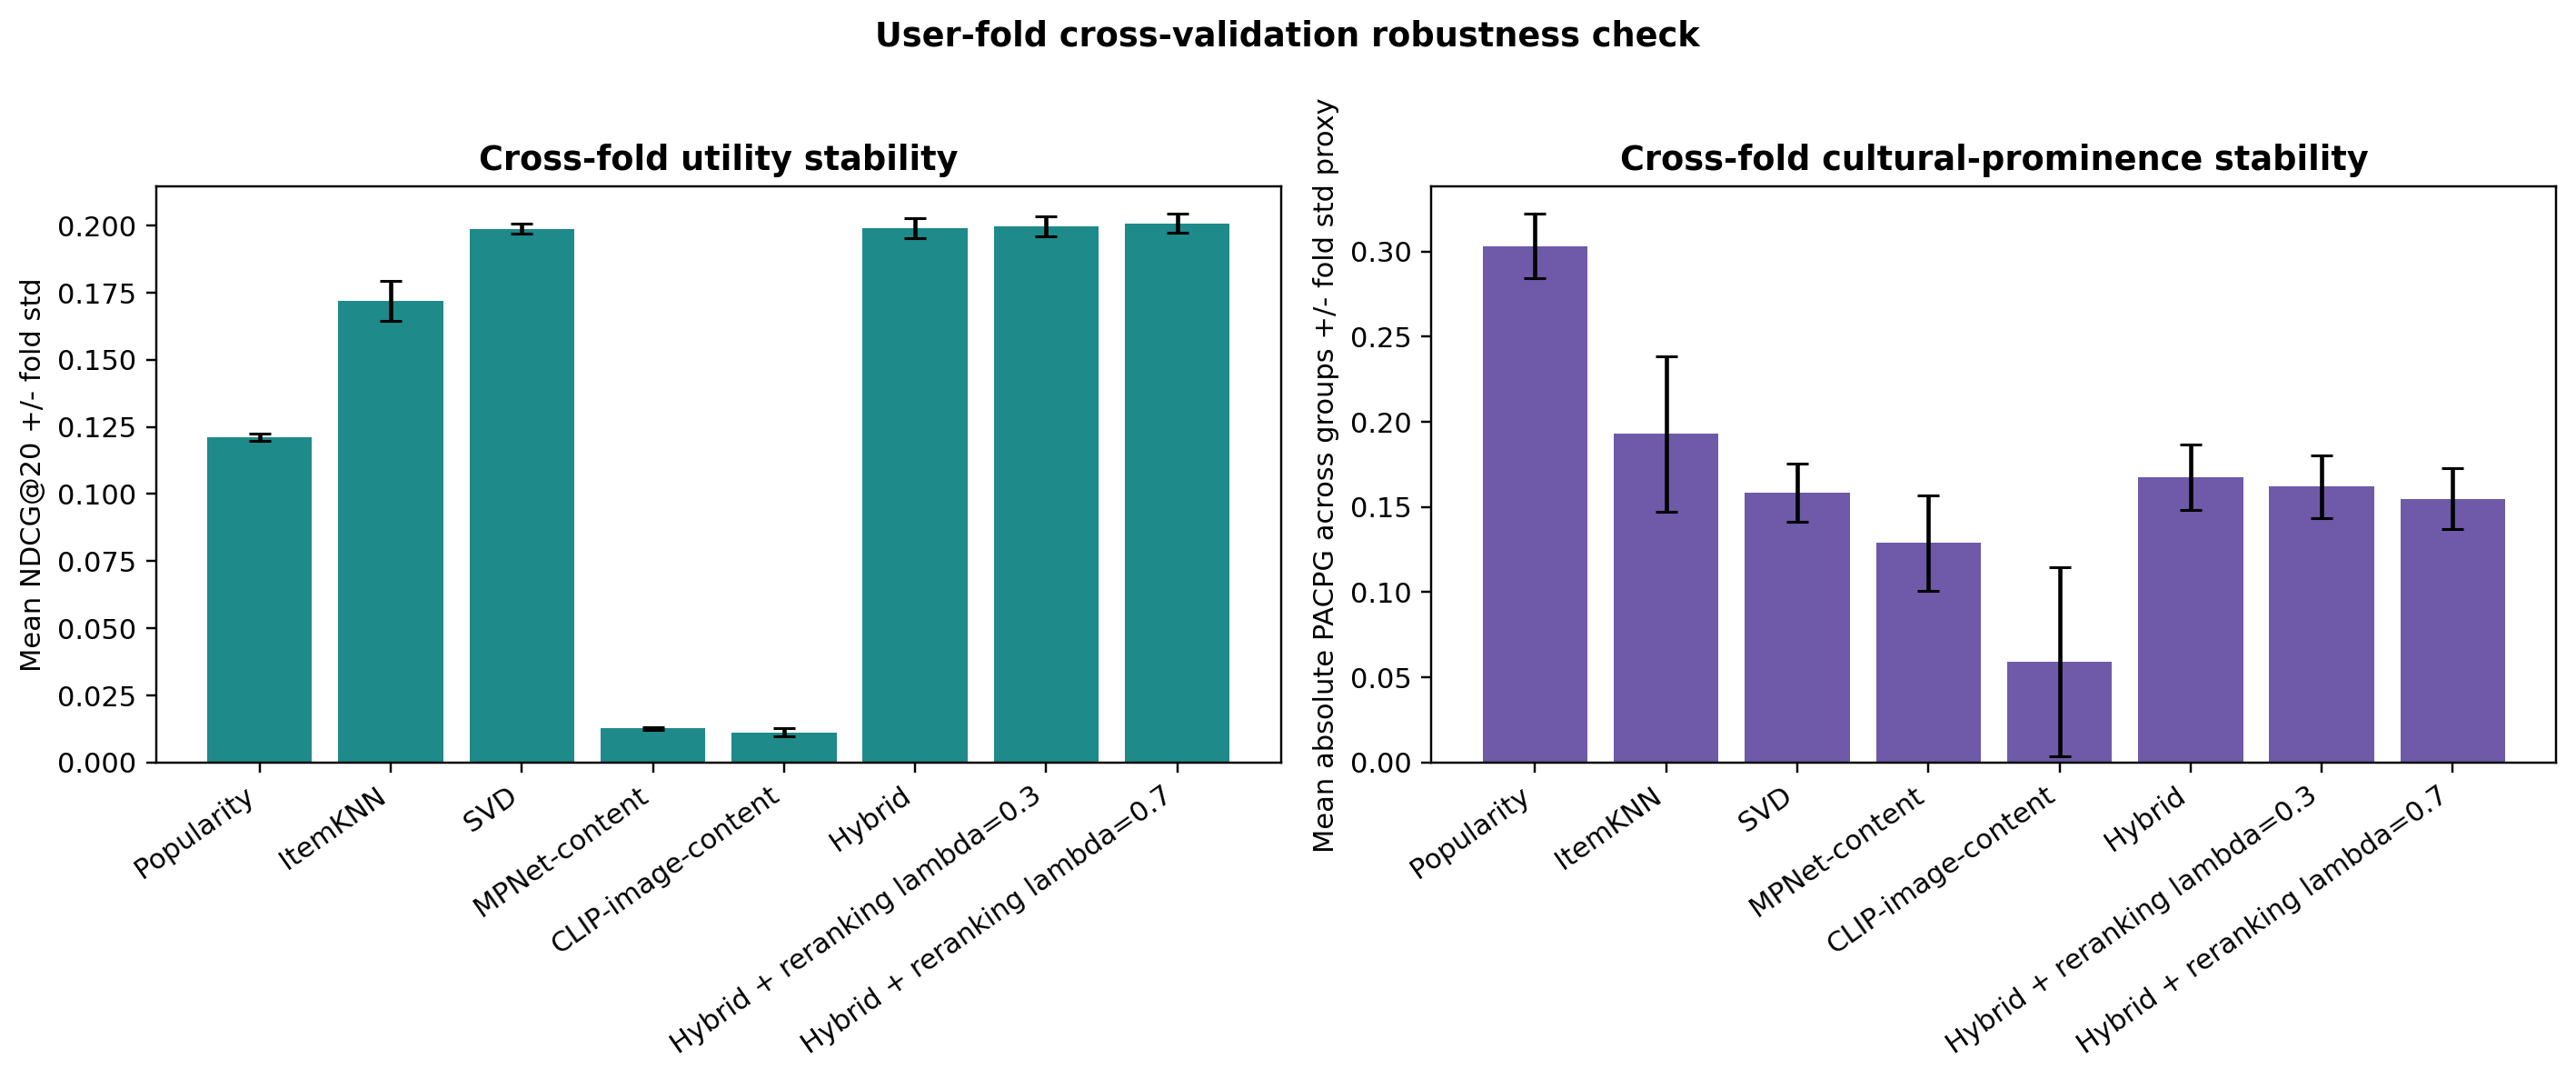

In [6]:
display(Image(filename=str(OUTPUTS / "15_cv_metric_stability.png")))


## 6. Fold-Level Audit Table

The fold table is deliberately kept visible. If a model looks strong on average but unstable across folds, the final write-up should treat it more cautiously.


In [7]:
fold_cols = [
    "Fold",
    "Model",
    f"NDCG@{TOP_K}",
    f"Recall@{TOP_K}",
    f"Coverage@{TOP_K}",
    "European Exposure@20",
    "Non-English Exposure@20",
    "PACPG European",
    "PACPG Non-English",
    "PACPG Long-tail",
]
display(cv_fold_results[fold_cols].round(4))


,Fold,Model,NDCG@20,Recall@20,Coverage@20,European Exposure@20,Non-English Exposure@20,PACPG European,PACPG Non-English,PACPG Long-tail
0,1,Popularity,0.1227,0.1614,0.0128,0.0803,0.0000,-0.2140,-0.0712,-0.0000
1,1,ItemKNN,0.1790,0.2237,0.1280,0.1935,0.0053,-0.1008,-0.0660,0.0002
2,1,SVD,0.2006,0.2596,0.1072,0.1949,0.0260,-0.0994,-0.0452,-0.0000
3,1,MPNet-content,0.0131,0.0207,0.1270,0.1943,0.0583,-0.1000,-0.0129,0.0003
4,1,CLIP-image-content,0.0107,0.0147,0.0844,0.2952,0.0132,0.0009,-0.0580,-0.0000
5,1,Hybrid,0.2002,0.2599,0.1061,0.1938,0.0211,-0.1004,-0.0501,-0.0000
6,1,Hybrid + reranking lambda=0.3,0.2004,0.2605,0.1063,0.1983,0.0219,-0.0960,-0.0493,-0.0000
7,1,Hybrid + reranking lambda=0.7,0.2014,0.2629,0.1068,0.2039,0.0229,-0.0904,-0.0483,-0.0000
8,2,Popularity,0.1200,0.1594,0.0134,0.0750,0.0001,-0.2292,-0.0804,-0.0001
9,2,ItemKNN,0.1643,0.2109,0.1413,0.2013,0.0110,-0.1028,-0.0695,-0.0000


## 7. What This Adds to the Proposal

The main proposal already demonstrates an end-to-end audit. This notebook adds model validation discipline:

- the models are rebuilt per fold instead of being treated as static outputs;
- the evaluation includes both recommender utility and cultural-prominence metrics;
- re-ranking is validated as an explicit post-processing intervention;
- the interpretation separates robust patterns from fold-sensitive patterns.

For the final project, the next step is to keep the same pipeline but add stratified analyses by genre, user activity segment and metadata coverage group.
